In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
from loaders._gen_binary import generate_data

In [3]:
pack = generate_data(seed=0, verbose=True)

Generated dataset with 1995 samples.
Shapes: [(1596, 25), (0, 25), (399, 25)]


In [4]:
bacc_tracks = {
    "RM": {
        "ens": [],
        "non-ens": []
    },
    "PD": {
        "ens": [],
        "non-ens": []
    },
    "CC": {
        "ens": [],
        "non-ens": []
    }
}

# SSL Random Masking

In [5]:
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from typing import Optional
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

def ssl_random_masking(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    *,
    n_models: int = 7,
    keep_ratio: float = 0.3,          # tỉ lệ giữ nhãn trong mỗi train-fold (phần sớm theo thời gian)
    tss_folds: int = 5,
    selftrain_threshold: float = 0.9,  # ngưỡng tin cậy để pseudo-label trong SelfTraining
    base_max_iter: int = 2000,
    random_state: int = 0,
) -> float:
    """
    Ensemble semi-supervised bằng cách 'ẩn nhãn theo thời gian' trong mỗi train-fold (TimeSeriesSplit),
    stacking bằng meta-learner từ OOF, và trả về balanced accuracy trên test.

    Tham số chính:
        - n_models: số base models trong ensemble
        - keep_ratio: tỉ lệ mẫu *đầu tiên theo thời gian* trong mỗi train-fold được giữ nhãn (còn lại là unlabeled)
        - tss_folds: số fold cho TimeSeriesSplit (dùng để tạo OOF và huấn luyện meta-learner)
        - selftrain_threshold: ngưỡng xác suất để SelfTraining chấp nhận pseudo-label
        - base_max_iter: số vòng lặp tối đa cho LogisticRegression (base estimator)
        - random_state: seed gốc (sẽ được xáo trộn cho từng base)

    Ghi chú:
        - Phù hợp binary classification (nhãn 0/1).
        - Tôn trọng tính thời gian: giữ nhãn ở phần *early* của train-fold để tránh leakage tương lai.
    """
    rng = np.random.RandomState(random_state)
    n_train = X_train.shape[0]

    # --- Khởi tạo M base estimators (LogisticRegression) và SelfTraining wrappers với seeds khác nhau ---
    base_templates = []
    for m in range(n_models):
        seed_m = rng.randint(0, 2**31 - 1)
        base = LogisticRegression(
            solver="lbfgs",
            max_iter=base_max_iter,
            class_weight="balanced",
            random_state=seed_m,
        )
        # SelfTraining cần estimator có predict_proba:
        st = SelfTrainingClassifier(
            base_estimator=base,
            threshold=selftrain_threshold,
            verbose=False
        )
        base_templates.append(st)

    # --- TimeSeriesSplit để tạo OOF predictions cho meta-learner ---
    tss = TimeSeriesSplit(n_splits=tss_folds)
    # Chúng ta sẽ lưu OOF prob của lớp 1 cho từng model => (n_train, n_models), mặc định NaN
    oof_probs = np.full((n_train, n_models), np.nan, dtype=float)

    # Helper: tạo y_masked cho một tập chỉ mục train_idx (giữ nhãn phần sớm theo thời gian)
    def make_masked_labels(train_idx: np.ndarray, keep_ratio_local: float) -> np.ndarray:
        y_mask = -np.ones_like(y_train, dtype=int)     # mặc định unlabeled
        # Giữ nhãn cho phần sớm của *train_idx*
        k = max(1, int(np.floor(keep_ratio_local * len(train_idx))))
        early_idx = train_idx[:k]  # phần đầu theo thời gian
        y_mask[early_idx] = y_train[early_idx]
        return y_mask

    # --- Vòng OOF: huấn luyện từng base trên mỗi fold và dự đoán trên val_idx ---
    for fold_id, (tr_idx, val_idx) in enumerate(tss.split(X_train, y_train)):
        # Đảm bảo chỉ dùng dữ liệu trước thời điểm val để huấn luyện
        for m in range(n_models):
            # Để đa dạng thêm chút, rung keep_ratio ± nhỏ nhưng giữ trong [0.15, 0.6]
            jitter = rng.uniform(-0.05, 0.05)
            keep_ratio_m = np.clip(keep_ratio + jitter, 0.15, 0.6)

            y_mask = make_masked_labels(tr_idx, keep_ratio_m)

            # Fit self-training trên phần train (nhưng y_mask có -1 ở ngoài tr_idx, nên chốt lại tập con)
            st_clf = clone(base_templates[m])
            # Chỉ khớp trên tr_idx để tránh ảnh hưởng các phần tử khác
            st_clf.fit(X_train[tr_idx], y_mask[tr_idx])

            # Dự đoán xác suất lớp 1 trên val
            p_val = st_clf.predict_proba(X_train[val_idx])[:, 1]
            oof_probs[val_idx, m] = p_val

    # --- Huấn luyện meta-learner trên các hàng có OOF đầy đủ (không NaN ở hàng đó) ---
    valid_rows = np.isfinite(oof_probs).all(axis=1)
    if valid_rows.sum() < max(30, n_models * 5):
        # Nếu quá ít OOF (ví dụ do quá ít fold), fallback dùng trung bình đều
        use_meta = False
    else:
        use_meta = True

    if use_meta:
        meta = LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=random_state + 2025
        )
        meta.fit(oof_probs[valid_rows], y_train[valid_rows])

    # --- Huấn luyện lại các base model trên *toàn bộ* train (mask theo thời gian toàn cục) ---
    final_models = []
    # Tạo mask toàn cục: giữ nhãn cho phần sớm của toàn bộ train
    k_global = max(1, int(np.floor(keep_ratio * n_train)))
    y_mask_global = -np.ones_like(y_train, dtype=int)
    y_mask_global[:k_global] = y_train[:k_global]

    for m in range(n_models):
        st_clf = clone(base_templates[m])
        st_clf.fit(X_train, y_mask_global)
        final_models.append(st_clf)

    # --- Suy luận trên test ---
    test_feats = []
    for m in range(n_models):
        p = final_models[m].predict_proba(X_test)[:, 1]
        test_feats.append(p.reshape(-1, 1))
    test_feats = np.hstack(test_feats)  # (n_test, n_models)

    if use_meta:
        # Stacking bằng meta-learner
        p_test = meta.predict_proba(test_feats)[:, 1]
    else:
        # Fallback: trung bình đều
        p_test = test_feats.mean(axis=1)

    y_pred = (p_test >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [6]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    bacc = ssl_random_masking(
        X_train, y_train, X_test, y_test,
        n_models=10,
        keep_ratio=0.3,
        tss_folds=3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["RM"]["ens"].append(bacc)
    print(f"Seed {seed:2d}: BAcc = {bacc:.4f}")

print(f"Mean = {np.mean(bacc_tracks['RM']['ens']):.4f} | Std = {np.std(bacc_tracks['RM']['ens']):.4f}")

Seed  0: BAcc = 0.6919


Seed  1: BAcc = 0.6581


Seed  2: BAcc = 0.6579


Seed  3: BAcc = 0.6390


Seed  4: BAcc = 0.6546


...

Seed 25: BAcc = 0.6835


Seed 26: BAcc = 0.6549


Seed 27: BAcc = 0.6839


Seed 28: BAcc = 0.6685


Seed 29: BAcc = 0.7192
Mean = 0.6787 | Std = 0.0219


## 2. Non-Ensemble

In [7]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    bacc = ssl_random_masking(
        X_train, y_train, X_test, y_test,
        n_models=1,
        keep_ratio=0.3,
        tss_folds=3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["RM"]["non-ens"].append(bacc)
    print(f"Seed {seed:2d}: BAcc = {bacc:.4f}")

print(f"Mean = {np.mean(bacc_tracks['RM']['non-ens']):.4f} | Std = {np.std(bacc_tracks['RM']['non-ens']):.4f}")

Seed  0: BAcc = 0.6893


Seed  1: BAcc = 0.6580


Seed  2: BAcc = 0.6550


Seed  3: BAcc = 0.6390


Seed  4: BAcc = 0.6521


...

Seed 25: BAcc = 0.6862


Seed 26: BAcc = 0.6575


Seed 27: BAcc = 0.6839


Seed 28: BAcc = 0.6681


Seed 29: BAcc = 0.7192
Mean = 0.6786 | Std = 0.0219


# SSL Progressive Distillation

In [8]:
def ssl_progressive_distillation(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    *,
    n_segments: int = 5,
    n_models: int = 7,
    keep_ratio: float = 0.3,           # phần đầu của mỗi segment được giữ nhãn (respect time)
    selftrain_threshold: float = 0.9,  # ngưỡng pseudo-label cho SelfTraining
    distill_alpha: float = 0.7,        # trọng số cho phần distillation (0..1)
    base_max_iter: int = 2000,
    random_state: int = 42,
) -> float:
    """
    Progressive segment-wise SSL + Sequential Distillation + Ensemble (sklearn only).
    Trả về balanced accuracy trên test.

    Giả định y là nhị phân {0,1}. Dữ liệu đã được sắp theo thời gian (hàng sau là thời điểm muộn hơn).
    """

    rng = np.random.RandomState(random_state)
    n = X_train.shape[0]
    assert n_segments >= 2, "Cần ít nhất 2 segment để 'distill liên tiếp'."

    # ---- Helper: chia chỉ mục thành n_segments khối liên tiếp theo thời gian ----
    def time_segments(n_samples: int, k: int):
        sizes = np.full(k, n_samples // k, dtype=int)
        sizes[: n_samples % k] += 1
        starts = np.cumsum(np.r_[0, sizes[:-1]])
        idxs = [np.arange(s, s + sz) for s, sz in zip(starts, sizes)]
        return idxs

    segs = time_segments(n, n_segments)

    # ---- Khởi tạo template base estimator & wrapper SSL ----
    def make_ssl(seed: int):
        base = LogisticRegression(
            solver="lbfgs",
            max_iter=base_max_iter,
            class_weight="balanced",
            random_state=seed,
        )
        st = SelfTrainingClassifier(base_estimator=base, threshold=selftrain_threshold, verbose=False)
        return st

    def make_supervised(seed: int):
        return LogisticRegression(
            solver="lbfgs",
            max_iter=base_max_iter,
            class_weight="balanced",
            random_state=seed,
        )

    # ---- Helper: tạo mask nhãn trong một segment (giữ nhãn phần đầu) ----
    def mask_labels_in_segment(y: np.ndarray, seg_idx: np.ndarray, keep: float) -> np.ndarray:
        y_mask = -np.ones_like(y, dtype=int)
        k = max(1, int(np.floor(keep * len(seg_idx))))
        early = seg_idx[:k]  # phần đầu theo thời gian trong segment
        y_mask[early] = y[early]
        return y_mask

    # ---- Helper: huấn luyện ensemble SSL trên 1 segment ----
    def fit_ssl_ensemble_on_segment(seg_idx: np.ndarray, seeds: np.ndarray):
        models = []
        # mask nhãn chỉ trong segment; ngoài segment không dùng khi fit (cắt theo seg_idx)
        y_mask = mask_labels_in_segment(y_train, seg_idx, keep_ratio)
        for m in range(n_models):
            st = make_ssl(int(seeds[m]))
            st.fit(X_train[seg_idx], y_mask[seg_idx])  # fit chỉ trên dữ liệu segment k
            models.append(st)
        return models

    # ---- Helper: suy luận soft prob trung bình của ensemble trên một tập chỉ mục ----
    def ensemble_mean_proba(models, X):
        ps = [mdl.predict_proba(X)[:, 1] for mdl in models]
        return np.mean(ps, axis=0)

    # ---- Trick distillation (không DL): huấn luyện LogisticRegression với 'soft labels' p in [0,1]
    # Bằng cách nhân đôi mẫu: (x, y=0, w=1-p) và (x, y=1, w=p), kết hợp phần có nhãn thật.
    def fit_student_with_soft(
        X_L: np.ndarray, y_L: np.ndarray,          # phần có nhãn thật (early trong segment)
        X_U: np.ndarray, p_U: np.ndarray,          # phần còn lại với soft prob từ teacher
        seed: int
    ):
        X_list = [X_L]
        y_list = [y_L.astype(int)]
        w_list = [np.ones(len(y_L), dtype=float)]  # supervised weight = 1.0

        # Distill cho phần U: tách thành 2 bản ghi cho mỗi điểm với weights (1-p, p)
        if len(X_U) > 0:
            X0 = X_U
            X1 = X_U
            y0 = np.zeros(len(X_U), dtype=int)
            y1 = np.ones(len(X_U), dtype=int)
            w0 = distill_alpha * (1.0 - p_U)
            w1 = distill_alpha * p_U

            X_list += [X0, X1]
            y_list += [y0, y1]
            w_list += [w0, w1]

        X_ext = np.vstack(X_list)
        y_ext = np.concatenate(y_list)
        w_ext = np.concatenate(w_list)

        clf = make_supervised(seed)
        clf.fit(X_ext, y_ext, sample_weight=w_ext)
        return clf

    # ============ 1) Train teacher ensemble trên segment 0 ============
    seeds = rng.randint(0, 2**31 - 1, size=n_models)
    current_ensemble = fit_ssl_ensemble_on_segment(segs[0], seeds)

    # ============ 2) Progressive distillation qua các segment tiếp theo ============
    for k in range(1, n_segments):
        seg_prev = segs[k - 1]
        seg_cur  = segs[k]

        # Teacher (k-1) tạo soft prob trên segment k (tôn trọng thời gian)
        p_soft_cur = ensemble_mean_proba(current_ensemble, X_train[seg_cur])

        # Chia segment k thành early (labeled) và late (unlabeled → distilled)
        k_keep = max(1, int(np.floor(keep_ratio * len(seg_cur))))
        early_idx = seg_cur[:k_keep]
        late_idx  = seg_cur[k_keep:]

        X_L, y_L = X_train[early_idx], y_train[early_idx]
        X_U, p_U = X_train[late_idx],  p_soft_cur[k_keep:]

        # Huấn luyện n student models trên segment k với distillation
        new_ensemble = []
        seeds = rng.randint(0, 2**31 - 1, size=n_models)
        for m in range(n_models):
            student_m = fit_student_with_soft(X_L, y_L, X_U, p_U, int(seeds[m]))
            new_ensemble.append(student_m)

        # Cập nhật: ensemble mới trở thành "teacher" cho vòng kế
        current_ensemble = new_ensemble

    # ============ 3) Suy luận trên test bằng ensemble cuối cùng ============
    p_test = ensemble_mean_proba(current_ensemble, X_test)
    y_pred = (p_test >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [9]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_progressive_distillation(
        X_train, y_train, X_test, y_test,
        n_segments=3,
        n_models=10,
        keep_ratio=0.3,
        selftrain_threshold=0.7,
        distill_alpha=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["PD"]["ens"].append(bacc)
    print(f"Seed {seed}: BAcc = {bacc:.4f}")

print("Mean balanced accuracy:", np.mean(bacc_tracks["PD"]["ens"]))
print("Standard deviation:", np.std(bacc_tracks["PD"]["ens"]))


Seed 0: BAcc = 0.6993


Seed 1: BAcc = 0.6647


Seed 2: BAcc = 0.6485


Seed 3: BAcc = 0.6336


Seed 4: BAcc = 0.6715


...

Seed 25: BAcc = 0.6823


Seed 26: BAcc = 0.6545


Seed 27: BAcc = 0.6660


Seed 28: BAcc = 0.6794


Seed 29: BAcc = 0.7194
Mean balanced accuracy: 0.6813212319540308
Standard deviation: 0.025154013948544003


## 2. Non-Ensemble

In [10]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_progressive_distillation(
        X_train, y_train, X_test, y_test,
        n_segments=3,
        n_models=1,
        keep_ratio=0.3,
        selftrain_threshold=0.7,
        distill_alpha=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["PD"]["non-ens"].append(bacc)
    print(f"Seed {seed}: BAcc = {bacc:.4f}")

print("Mean balanced accuracy:", np.mean(bacc_tracks["PD"]["non-ens"]))
print("Standard deviation:", np.std(bacc_tracks["PD"]["non-ens"]))


Seed 0: BAcc = 0.6993
Seed 1: BAcc = 0.6647


Seed 2: BAcc = 0.6485


Seed 3: BAcc = 0.6336


Seed 4: BAcc = 0.6715


Seed 5: BAcc = 0.6721


...

Seed 20: BAcc = 0.6763


Seed 21: BAcc = 0.7020
Seed 22: BAcc = 0.6830


Seed 23: BAcc = 0.6282
Seed 24: BAcc = 0.6892
Seed 25: BAcc = 0.6823


Seed 26: BAcc = 0.6545
Seed 27: BAcc = 0.6660
Seed 28: BAcc = 0.6794


Seed 29: BAcc = 0.7194
Mean balanced accuracy: 0.6813212319540308
Standard deviation: 0.025154013948544003


# SSL Cross-view Co-training

In [11]:
import numpy as np
from typing import Optional, Sequence, Tuple
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone


def ssl_crossview_cotraining(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    *,
    # ---- time-aware labeled / unlabeled split ----
    keep_ratio: float = 0.3,          # phần đầu của train giữ nhãn (tôn trọng thời gian)
    # ---- co-training loop ----
    n_iter: int = 10,                  # số vòng co-training
    add_per_class: int = 50,           # mỗi vòng, mỗi view chọn tối đa k mẫu/ lớp để gán cho view kia
    threshold: float = 0.9,            # ngưỡng tin cậy tối thiểu; nếu không đủ mẫu đạt ngưỡng thì có thể chọn ít hơn
    # ---- ensemble over multiple view splits / seeds ----
    n_models: int = 5,                 # số cặp mô hình (ensemble size)
    view_split_strategy: str = "alternating",  # "alternating" | "random"
    random_state: int = 42,
    # ---- model configs ----
    lr_max_iter: int = 2000,
    rf_estimators: int = 300,
    rf_min_samples_leaf: int = 1,
    # ---- optional explicit view indices ----
    view1_idx: Optional[Sequence[int]] = None,
    view2_idx: Optional[Sequence[int]] = None,
) -> float:
    """
    SSL Cross-view / Co-Training (sklearn-only), time-aware, with ensemble.
    - Nhãn thật chỉ ở phần đầu (keep_ratio) của train; phần còn lại dùng co-training để tạo pseudo-label.
    - Hai view đặc trưng (có thể cung cấp thủ công; mặc định: tách cột chẵn/lẻ hoặc tách ngẫu nhiên).
    - Mỗi vòng: View A gán nhãn các mẫu tự tin nhất (mỗi lớp ≤ add_per_class) để thêm vào tập labeled của View B, và ngược lại.
    - Lặp nhiều cặp (ensemble) để tăng đa dạng; cuối cùng soft-vote xác suất trên test.

    Trả về:
        balanced_accuracy_score trên (X_test, y_test).
    """
    rng_global = np.random.RandomState(random_state)
    n_train, d = X_train.shape
    assert y_train.ndim == 1 and set(np.unique(y_train)).issubset({0, 1}), "Hàm này hiện hỗ trợ nhị phân 0/1."

    # --------- helper: build two base learners for the two views ---------
    def build_learners(seed_a: int, seed_b: int):
        # View A: chuẩn hoá + LogisticRegression
        clf_a = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            LogisticRegression(
                solver="lbfgs",
                class_weight="balanced",
                max_iter=lr_max_iter,
                random_state=seed_a,
            ),
        )
        # View B: RandomForest (đa dạng hoá hypothesis)
        clf_b = RandomForestClassifier(
            n_estimators=rf_estimators,
            min_samples_leaf=rf_min_samples_leaf,
            class_weight="balanced_subsample",
            random_state=seed_b,
            n_jobs=-1,
        )
        return clf_a, clf_b

    # --------- helper: split features into two views ---------
    def make_views(d: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
        if view1_idx is not None and view2_idx is not None:
            v1 = np.array(list(view1_idx), dtype=int)
            v2 = np.array(list(view2_idx), dtype=int)
            assert len(set(v1).intersection(set(v2))) == 0, "view1_idx và view2_idx không được chồng lấn."
            assert len(v1) > 0 and len(v2) > 0, "Mỗi view cần ≥1 đặc trưng."
            return v1, v2

        if view_split_strategy == "alternating":
            v1 = np.arange(0, d, 2)  # cột 0,2,4,...
            v2 = np.arange(1, d, 2)  # cột 1,3,5,...
            if len(v1) == 0 or len(v2) == 0:  # d=1 edge-case
                # ép chia tối thiểu 1-1
                mid = max(1, d // 2)
                v1 = np.arange(0, mid)
                v2 = np.arange(mid, d)
            return v1, v2
        elif view_split_strategy == "random":
            rs = np.random.RandomState(seed)
            perm = rs.permutation(d)
            mid = max(1, d // 2)
            v1 = np.sort(perm[:mid])
            v2 = np.sort(perm[mid:])
            return v1, v2
        else:
            raise ValueError("view_split_strategy phải là 'alternating' hoặc 'random'.")

    # --------- helper: chọn mẫu tự tin nhất theo từng lớp ---------
    def select_confident(per_probs: np.ndarray, u_idx: np.ndarray, k: int, thr: float):
        """
        per_probs: xác suất lớp 1 cho các điểm U, shape (|U|,)
        u_idx: chỉ số gốc trong X_train tương ứng
        Trả về: (idx_pos, idx_neg) là mảng chỉ số gốc được chọn (theo từng lớp)
        """
        conf = np.maximum(per_probs, 1.0 - per_probs)
        # Lọc đạt ngưỡng
        mask_thr = conf >= thr
        cand_idx = u_idx[mask_thr]
        cand_prob = per_probs[mask_thr]

        # Chọn top-k từng lớp theo độ tin cậy
        def topk_for_class(cls: int):
            if cand_idx.size == 0:
                return np.array([], dtype=int)
            if cls == 1:
                scores = cand_prob  # càng gần 1 càng tốt
            else:
                scores = 1.0 - cand_prob  # càng gần 1 (cho class 0) càng tốt
            # Lọc theo lớp
            if cls == 1:
                cls_mask = cand_prob >= 0.5
            else:
                cls_mask = cand_prob < 0.5
            idx_pool = cand_idx[cls_mask]
            sc_pool = scores[cls_mask]
            if idx_pool.size == 0:
                return np.array([], dtype=int)
            order = np.argsort(-sc_pool)  # descending
            take = min(k, idx_pool.size)
            return idx_pool[order[:take]]

        pos_idx = topk_for_class(1)
        neg_idx = topk_for_class(0)
        return pos_idx, neg_idx

    # --------- co-training for one ensemble member (one pair of views & learners) ---------
    def run_one_member(seed_member: int) -> np.ndarray:
        v1, v2 = make_views(d, seed_member)
        X1_train, X2_train = X_train[:, v1], X_train[:, v2]
        X1_test,  X2_test  = X_test[:,  v1],  X_test[:,  v2]

        # Time-aware split: L (early) has labels, U (late) unlabeled initially
        kL = max(1, int(np.floor(keep_ratio * n_train)))
        L_idx = np.arange(0, kL)
        U_idx = np.arange(kL, n_train)

        # Mỗi view giữ bộ labeled riêng (có thể khác nhau do nhận pseudo từ view kia)
        L1_idx = L_idx.copy()
        L2_idx = L_idx.copy()
        y1_lab = y_train[L1_idx].astype(int).copy()
        y2_lab = y_train[L2_idx].astype(int).copy()

        # Learners
        seed_a = seed_member * 2 + 1
        seed_b = seed_member * 2 + 2
        clf1, clf2 = build_learners(seed_a, seed_b)

        U = U_idx.copy()
        for it in range(n_iter):
            # fit hiện tại
            clf1.fit(X1_train[L1_idx], y1_lab)
            clf2.fit(X2_train[L2_idx], y2_lab)

            if U.size == 0:
                break

            # dự đoán trên U của từng view
            p1 = clf1.predict_proba(X1_train[U])[:, 1]
            p2 = clf2.predict_proba(X2_train[U])[:, 1]

            # mỗi view chọn mẫu tự tin nhất theo từng lớp để gán cho view kia
            pos1, neg1 = select_confident(p1, U, add_per_class, threshold)
            pos2, neg2 = select_confident(p2, U, add_per_class, threshold)

            add1 = np.concatenate([pos1, neg1])
            add2 = np.concatenate([pos2, neg2])

            # nếu cả hai không chọn được gì, dừng sớm
            if add1.size == 0 and add2.size == 0:
                break

            # gán nhãn pseudo (theo view nguồn) cho view kia
            def pseudo_labels_from_probs(idx_sel: np.ndarray, probs_all: np.ndarray, U_all: np.ndarray):
                if idx_sel.size == 0:
                    return np.array([], dtype=int)
                # map chỉ số gốc -> vị trí trong mảng probs_all
                pos = {u: i for i, u in enumerate(U_all)}
                loc = np.array([pos[u] for u in idx_sel], dtype=int)
                probs = probs_all[loc]
                return (probs >= 0.5).astype(int)

            y_from1 = pseudo_labels_from_probs(add1, p1, U)
            y_from2 = pseudo_labels_from_probs(add2, p2, U)

            # cập nhật labeled sets (tránh trùng lặp)
            if add2.size > 0:
                mask_new2 = ~np.isin(add2, L1_idx)
                L1_idx = np.concatenate([L1_idx, add2[mask_new2]])
                y1_lab = np.concatenate([y1_lab, y_from2[mask_new2]])
            if add1.size > 0:
                mask_new1 = ~np.isin(add1, L2_idx)
                L2_idx = np.concatenate([L2_idx, add1[mask_new1]])
                y2_lab = np.concatenate([y2_lab, y_from1[mask_new1]])

            # loại khỏi U các mẫu đã được bất kỳ view chọn
            remove = np.unique(np.concatenate([add1, add2])) if (add1.size + add2.size) > 0 else np.array([], dtype=int)
            if remove.size > 0:
                U = U[~np.isin(U, remove)]

        # Huấn luyện cuối cùng và dự đoán test
        clf1.fit(X1_train[L1_idx], y1_lab)
        clf2.fit(X2_train[L2_idx], y2_lab)
        p_test = 0.5 * clf1.predict_proba(X1_test)[:, 1] + 0.5 * clf2.predict_proba(X2_test)[:, 1]
        return p_test

    # --------- chạy ensemble ---------
    test_probs_all = []
    for m in range(n_models):
        seed_m = rng_global.randint(0, 2**31 - 1)
        test_probs_all.append(run_one_member(seed_m))
    p_test_ens = np.mean(np.vstack(test_probs_all), axis=0)

    y_pred = (p_test_ens >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [12]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_crossview_cotraining(
        X_train, y_train, X_test, y_test,
        keep_ratio=0.3,      # nhãn thật cho 30% đầu chuỗi thời gian
        n_iter=8,            # vòng co-training
        add_per_class=50,    # mỗi vòng, mỗi view thêm ≤50 mẫu/lớp cho view kia
        threshold=0.7,       # chỉ nhận mẫu rất tự tin
        n_models=10,          # ensemble 10 cặp view
        view_split_strategy="random",  # đa dạng hóa view
        random_state=42
    )
    bacc_tracks["CC"]["ens"].append(bacc)
    print(f"Seed {seed} - Balanced accuracy:", bacc)

print("Mean BAcc = ", np.mean(bacc_tracks["CC"]["ens"]))
print("Std BAcc = ", np.std(bacc_tracks["CC"]["ens"]))

Seed 0 - Balanced accuracy: 0.7068969849246232


Seed 1 - Balanced accuracy: 0.6699507389162562


Seed 2 - Balanced accuracy: 0.6502722597559746


Seed 3 - Balanced accuracy: 0.642512077294686


Seed 4 - Balanced accuracy: 0.6646690788481833


...

Seed 25 - Balanced accuracy: 0.6966632962588473


Seed 26 - Balanced accuracy: 0.6676636171710064


Seed 27 - Balanced accuracy: 0.701998491704374


Seed 28 - Balanced accuracy: 0.6766228845668099


Seed 29 - Balanced accuracy: 0.7066184230363335
Mean BAcc =  0.6833126369869104
Std BAcc =  0.02288549474332428


## 2. Non-Ensemble

In [13]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_crossview_cotraining(
        X_train, y_train, X_test, y_test,
        keep_ratio=0.3,      # nhãn thật cho 30% đầu chuỗi thời gian
        n_iter=8,            # vòng co-training
        add_per_class=50,    # mỗi vòng, mỗi view thêm ≤50 mẫu/lớp cho view kia
        threshold=0.7,       # chỉ nhận mẫu rất tự tin
        n_models=1,          # không ensemble
        view_split_strategy="random",  # đa dạng hóa view
        random_state=42
    )
    bacc_tracks["CC"]["non-ens"].append(bacc)
    print(f"Seed {seed} - Balanced accuracy:", bacc)

print("Mean BAcc = ", np.mean(bacc_tracks["CC"]["non-ens"]))
print("Std BAcc = ", np.std(bacc_tracks["CC"]["non-ens"]))

Seed 0 - Balanced accuracy: 0.701896984924623


Seed 1 - Balanced accuracy: 0.6725017593244194


Seed 2 - Balanced accuracy: 0.6529318342240596


Seed 3 - Balanced accuracy: 0.644927536231884


Seed 4 - Balanced accuracy: 0.6595055027890848


...

Seed 25 - Balanced accuracy: 0.6939459049544995


Seed 26 - Balanced accuracy: 0.6701266713581985


Seed 27 - Balanced accuracy: 0.7044494720965309


Seed 28 - Balanced accuracy: 0.6692472846678454


Seed 29 - Balanced accuracy: 0.7066561133725313
Mean BAcc =  0.682372313842301
Std BAcc =  0.021336712022913037


In [14]:
bacc_tracks

{'RM': {'ens': [0.6918718592964824,
   0.6580752990851513,
   0.6579106584652616,
   0.63900211352657,
   0.6546057590833709,
   0.668631245601689,
   0.7319597989949749,
   0.7216582914572864,
   0.7066049134111961,
   0.648816404483088,
   0.6872455902306649,
   0.6836937389992457,
   0.6664193369887821,
   0.6649479350067911,
   0.6787706689450671,
   0.6851646970077948,
   0.6741834170854272,
   0.6770455917874396,
   0.6870948288858736,
   0.7024393326592517,
   0.6670732934252226,
   0.6924882629107981,
   0.6782296650717703,
   0.6487750892902058,
   0.6795361939735398,
   0.6834681496461072,
   0.6549085151301901,
   0.6839366515837104,
   0.6685147764587017,
   0.7192446856625961],
  'non-ens': [0.6893467336683416,
   0.6579873328641801,
   0.6549611777755369,
   0.63900211352657,
   0.6520805065581186,
   0.668631245601689,
   0.7294472361809046,
   0.7216708542713568,
   0.7068188683044704,
   0.648816404483088,
   0.6872455902306649,
   0.6836937389992457,
   0.671273705920

# More Study on Keep Ratio

In [15]:
def ssl_rm(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_random_masking(
            X_train, y_train, X_test, y_test,
            n_models=10,
            keep_ratio=keep_ratio,
            tss_folds=3,
            selftrain_threshold=0.7,
            base_max_iter=2000,
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

def ssl_pd(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_progressive_distillation(
            X_train, y_train, X_test, y_test,
            n_segments=3,
            n_models=10,
            keep_ratio=keep_ratio,
            selftrain_threshold=0.7,
            distill_alpha=0.7,
            base_max_iter=2000,
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

def ssl_cc(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_crossview_cotraining(
            X_train, y_train, X_test, y_test,
            keep_ratio=keep_ratio,     
            n_iter=8,            
            add_per_class=50,    
            threshold=0.7,       
            n_models=10,         
            view_split_strategy="random",  
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

In [16]:
keep_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

tracks = {
    "RM": [],
    "PD": [],
    "CC": []
}

for ratio in keep_ratios:
    rm_mean, rm_std = ssl_rm(ratio)
    pd_mean, pd_std = ssl_pd(ratio)
    cc_mean, cc_std = ssl_cc(ratio)

    tracks["RM"].append((rm_mean, rm_std))
    tracks["PD"].append((pd_mean, pd_std))
    tracks["CC"].append((cc_mean, cc_std))

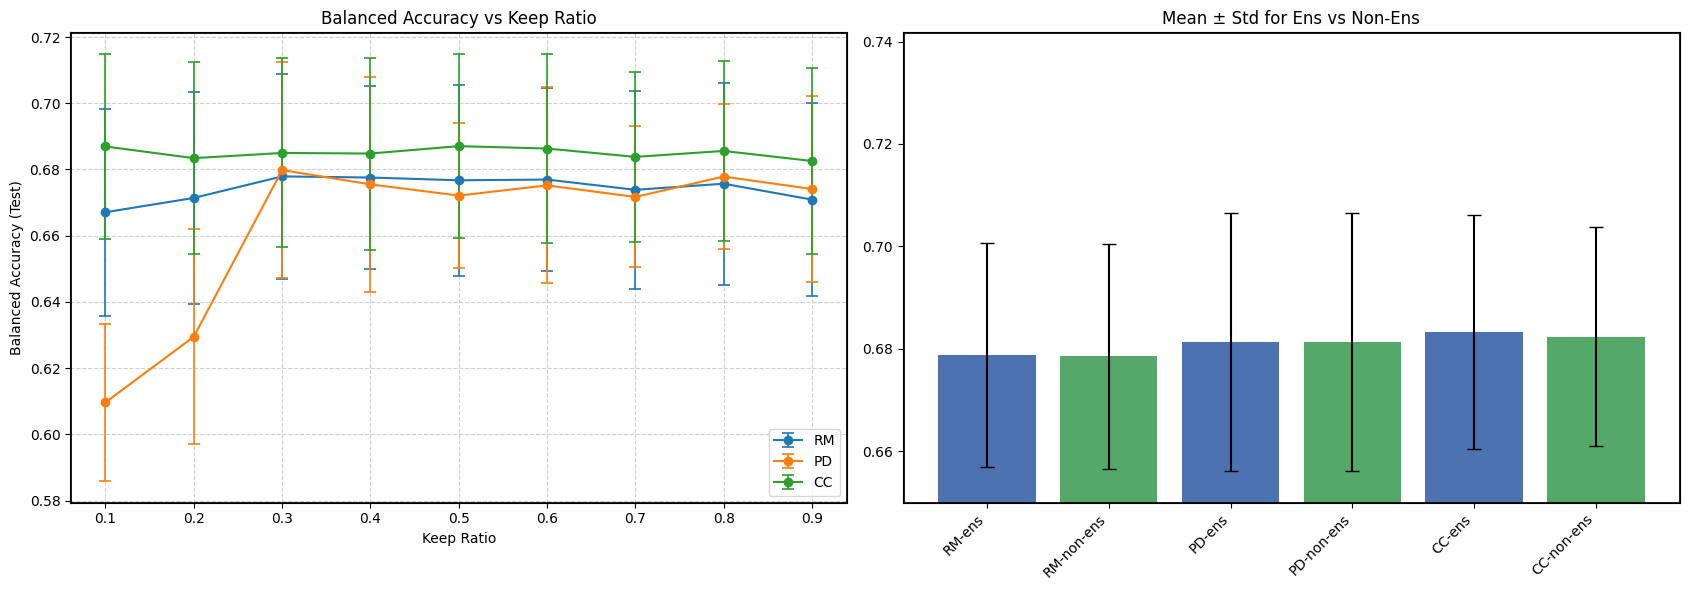

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(17,6))

# --- Subplot 1: line chart ---
ax = axes[0]
ratios = np.arange(0.1, 1.0, 0.1)
for method, values in tracks.items():
    means = [m for m, s in values]
    stds = [s for m, s in values]
    ax.errorbar(ratios, means, yerr=stds, label=method, capsize=4, 
                marker='o', linestyle='-', elinewidth=1.2, capthick=1.2)

ax.set_xlabel("Keep Ratio")
ax.set_ylabel("Balanced Accuracy (Test)")
ax.set_title("Balanced Accuracy vs Keep Ratio")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
# border
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
rect = plt.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor="black", facecolor="none", zorder=10)
ax.add_patch(rect)

# --- Subplot 2: bar chart ---
ax2 = axes[1]
labels = []
means = []
stds = []
for method in ["RM","PD","CC"]:
    for g in ["ens","non-ens"]:
        labels.append(f"{method}-{g}")
        m, s = np.mean(bacc_tracks[method][g]), np.std(bacc_tracks[method][g])
        means.append(m)
        stds.append(s)

x = np.arange(len(labels))
ax2.bar(x, means, yerr=stds, capsize=5, color=["#4c72b0","#55a868"]*3)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right")
# ax2.set_ylabel("Balanced Accuracy (Test)")
ax2.set_title("Mean ± Std for Ens vs Non-Ens")

# set ylim to start from 0.6
ax2.set_ylim(0.65, None)  # start from 0.6, auto-adjust upper limit

# border
x0, x1 = ax2.get_xlim()
y0, y1 = ax2.get_ylim()
rect2 = plt.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor="black", facecolor="none", zorder=10)
ax2.add_patch(rect2)

plt.tight_layout()
plt.show()